In [24]:
import pandas as pd
from matplotlib import pyplot as plt

# from trainer.src.influx_reader import load_data

# EDA

In [25]:
# df = load_data()

In [26]:
df = pd.read_csv("../datasets/sensors.csv")

In [27]:
df.shape

(11561, 12)

In [28]:
df.head()

,Unnamed: 0,time,device_id,current,failure,humidity,load,pressure,rpm,temperature,vibration,wear
0,0,2026-08-13T08:54:27.354064+00:00,motor_000,15.35,0,44.0,0.558,6.02,2143.0,59.94,0.63,0.0001
1,1,2026-08-13T08:54:28.644359+00:00,motor_000,15.55,0,49.7,0.539,6.09,2151.0,58.60,0.52,0.0003
2,2,2026-08-13T08:54:29.659000+00:00,motor_000,14.02,0,45.0,0.540,5.98,2170.0,58.83,0.58,0.0004
3,3,2026-08-13T08:54:30.673773+00:00,motor_000,14.93,0,46.0,0.541,5.91,2178.0,58.44,0.51,0.0005
4,4,2026-08-13T08:54:31.678822+00:00,motor_000,14.79,0,39.9,0.542,6.04,2154.0,59.65,0.61,0.0007


In [29]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 11561 entries, 0 to 11560
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   Unnamed: 0   11561 non-null  int64  
 1   time         11561 non-null  str    
 2   device_id    11561 non-null  str    
 3   current      11561 non-null  float64
 4   failure      11561 non-null  int64  
 5   humidity     11561 non-null  float64
 6   load         11561 non-null  float64
 7   pressure     11561 non-null  float64
 8   rpm          11561 non-null  float64
 9   temperature  11561 non-null  float64
 10  vibration    11561 non-null  float64
 11  wear         11561 non-null  float64
dtypes: float64(8), int64(2), str(2)
memory usage: 1.1 MB


In [30]:
df.describe()

,Unnamed: 0,current,failure,humidity,load,pressure,rpm,temperature,vibration,wear
count,11561.000000,11561.000000,11561.000000,11561.000000,11561.000000,11561.000000,11561.000000,11561.000000,11561.000000,11561.000000
mean,5780.000000,17.746659,0.003806,44.995987,0.699981,5.946397,2332.247989,65.328348,0.690173,0.025778
std,3337.517565,4.079930,0.061577,3.956554,0.218274,0.251728,292.075435,8.237194,0.348543,0.020452
min,0.000000,1.510000,0.000000,26.900000,0.200000,1.580000,171.000000,45.510000,0.260000,0.000100
25%,2890.000000,14.710000,0.000000,42.300000,0.534000,5.920000,2140.000000,59.180000,0.580000,0.009200
50%,5780.000000,18.640000,0.000000,45.100000,0.748000,5.960000,2396.000000,66.800000,0.690000,0.020700
75%,8670.000000,21.110000,0.000000,47.700000,0.883000,6.000000,2558.000000,71.630000,0.770000,0.038000
max,11560.000000,24.480000,1.000000,61.100000,1.000000,6.190000,2754.000000,113.960000,6.930000,0.098800


In [31]:
df["device_id"].nunique()

4

In [32]:
df["device_id"].value_counts()

device_id
motor_000    2946
motor_001    2946
motor_002    2864
motor_003    2805
Name: count, dtype: int64

In [33]:
df.groupby("device_id")["time"].agg(["min", "max", "count"])

,min,max,count
device_id,,,
motor_000,2026-08-13T08:54:27.354064+00:00,2026-08-13T09:44:04.283908+00:00,2946
motor_001,2026-08-13T08:54:27.451405+00:00,2026-08-13T09:44:04.286234+00:00,2946
motor_002,2026-08-13T08:54:27.411811+00:00,2026-08-13T09:44:04.286031+00:00,2864
motor_003,2026-08-13T08:54:27.484919+00:00,2026-08-13T09:44:04.286050+00:00,2805


# Some plots

In [34]:
features = df.columns.drop('time').drop('device_id')
features

Index(['Unnamed: 0', 'current', 'failure', 'humidity', 'load', 'pressure',
       'rpm', 'temperature', 'vibration', 'wear'],
      dtype='str')

In [35]:
device = "motor_001"

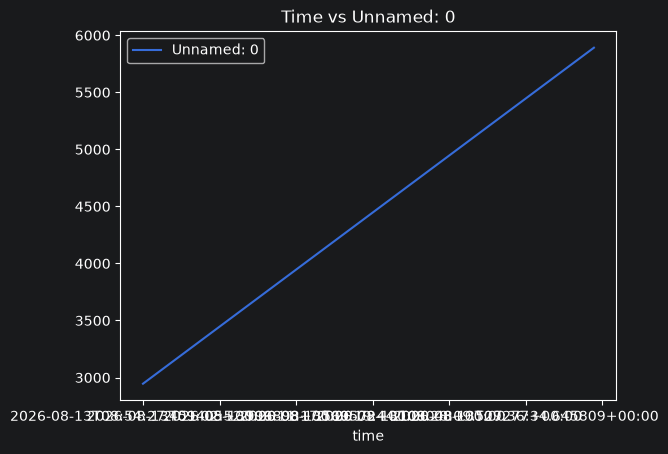

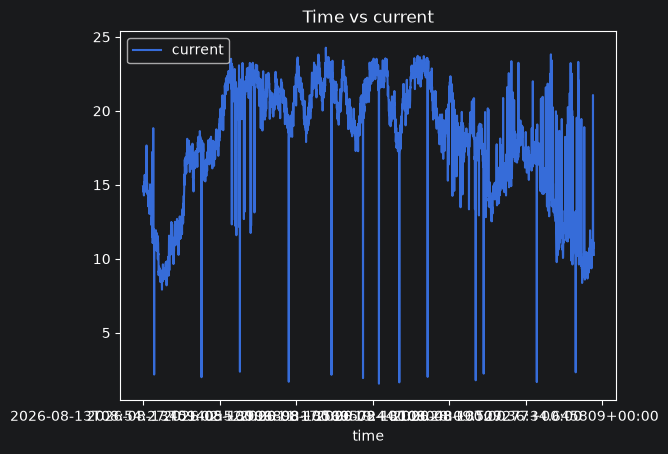

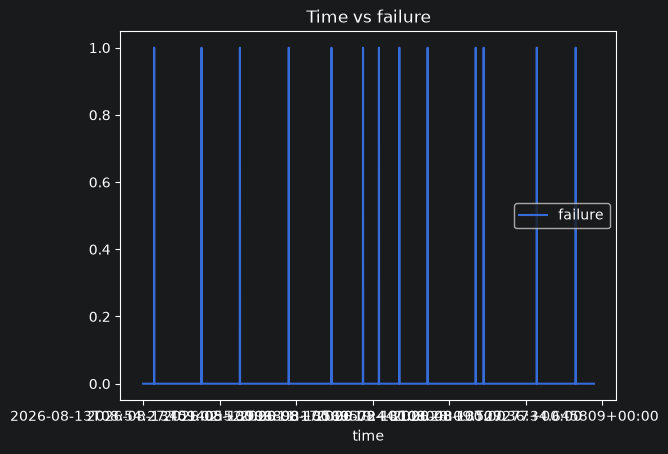

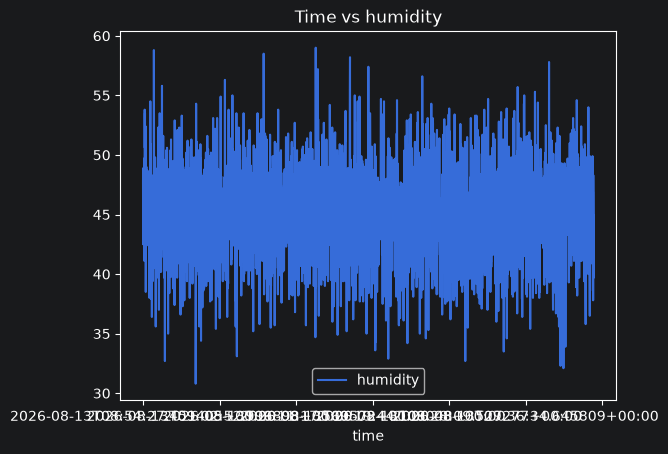

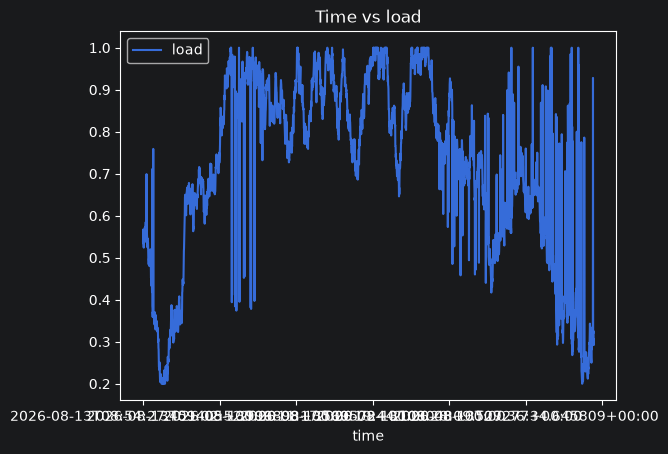

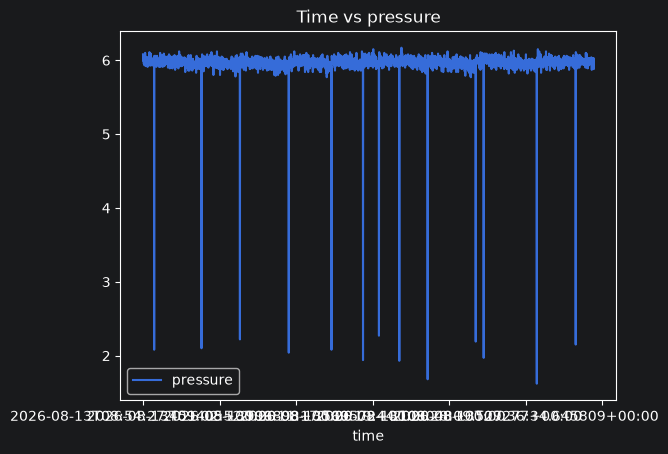

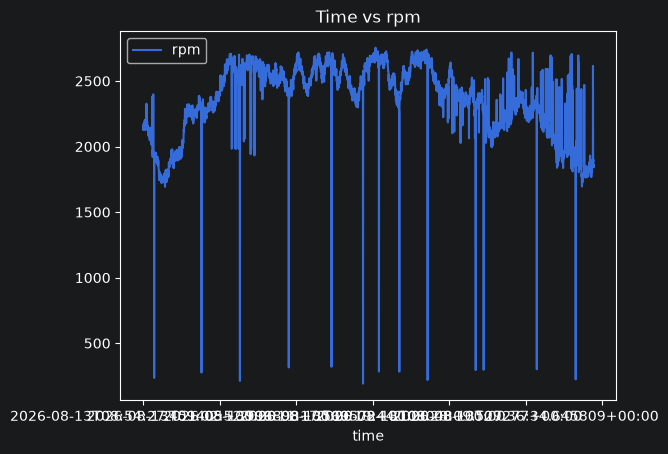

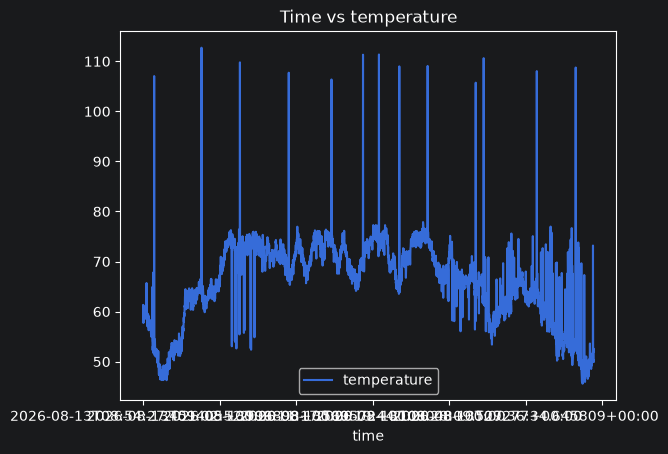

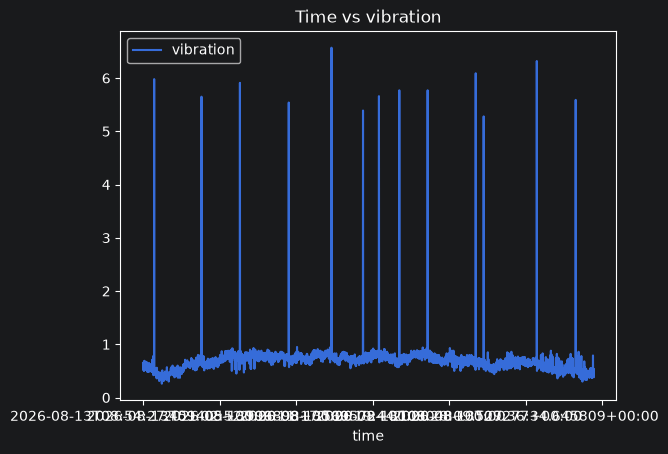

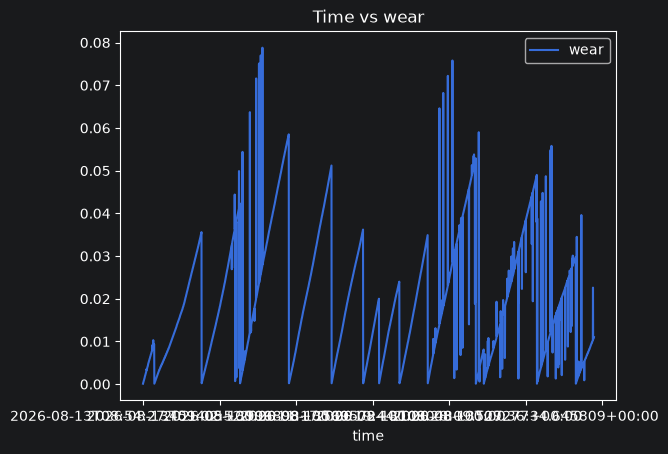

In [36]:
subset = df[df['device_id'] == device].drop(columns='device_id')

for feature in features:
    subset.plot(x='time',
                y=feature,
                title=f"Time vs {feature}")

looks like spikes in some features lead to spikes in failure, lets see

In [37]:
# time as index for faster plots
subset = subset.set_index('time')
subset.index = pd.to_datetime(subset.index)

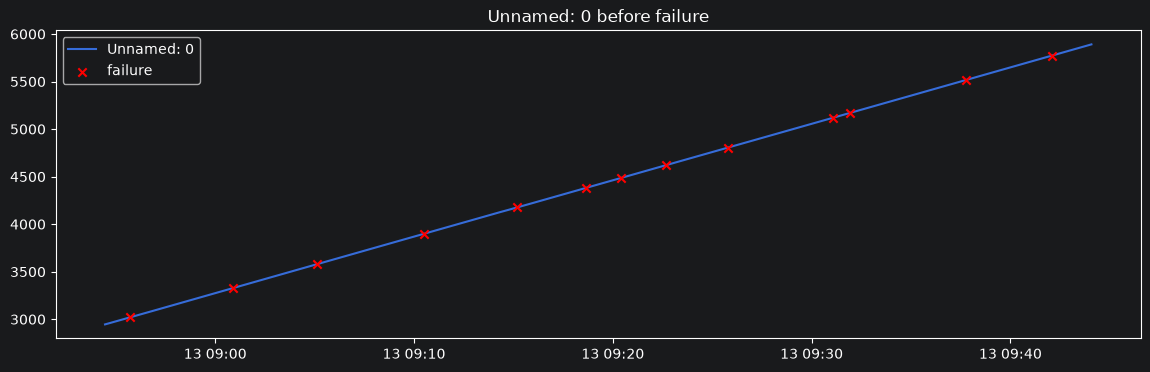

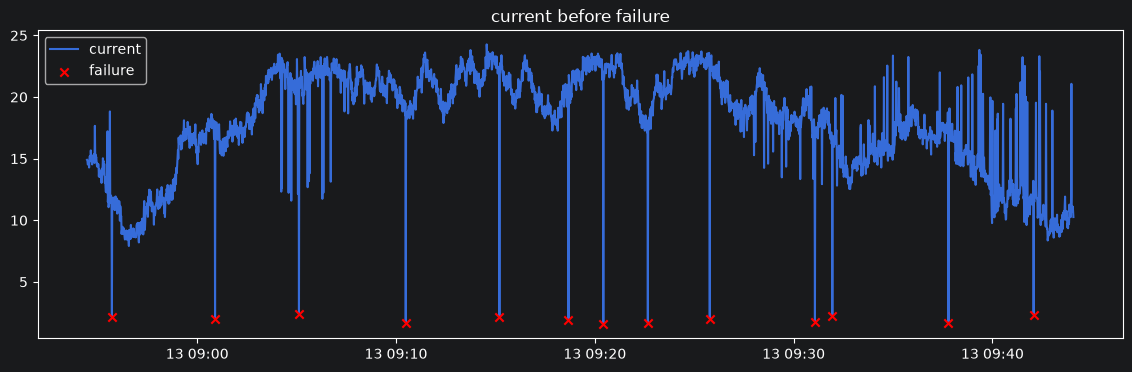

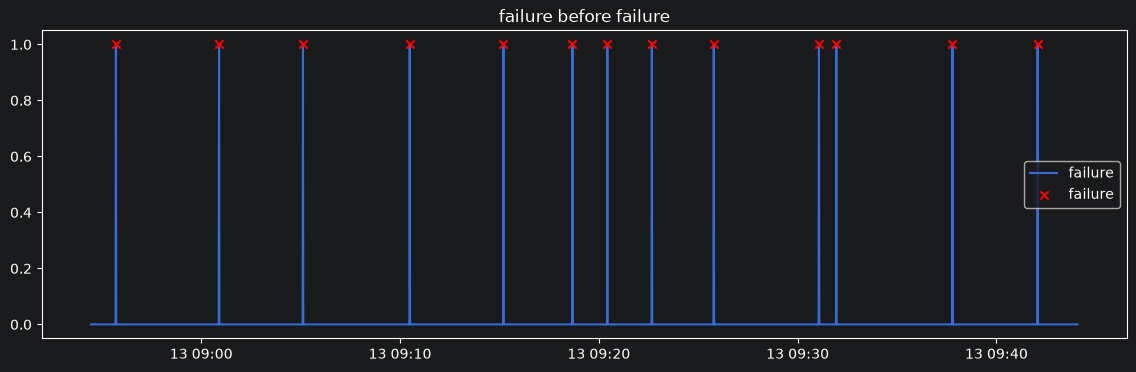

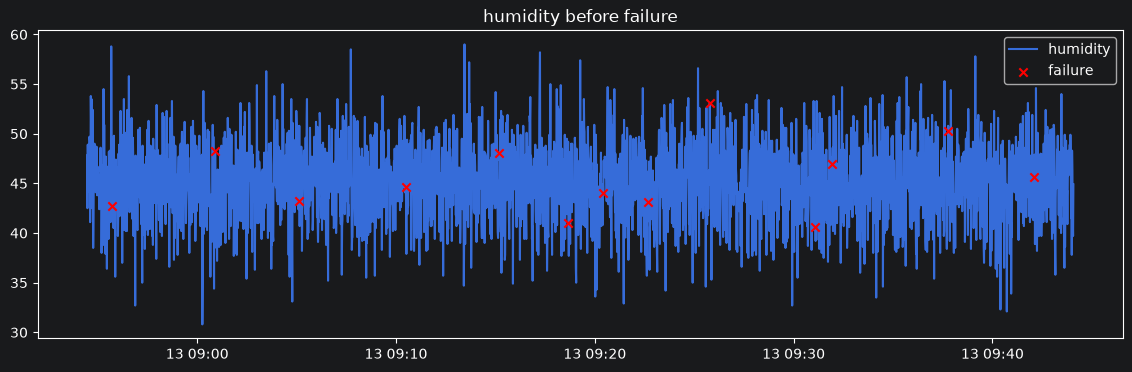

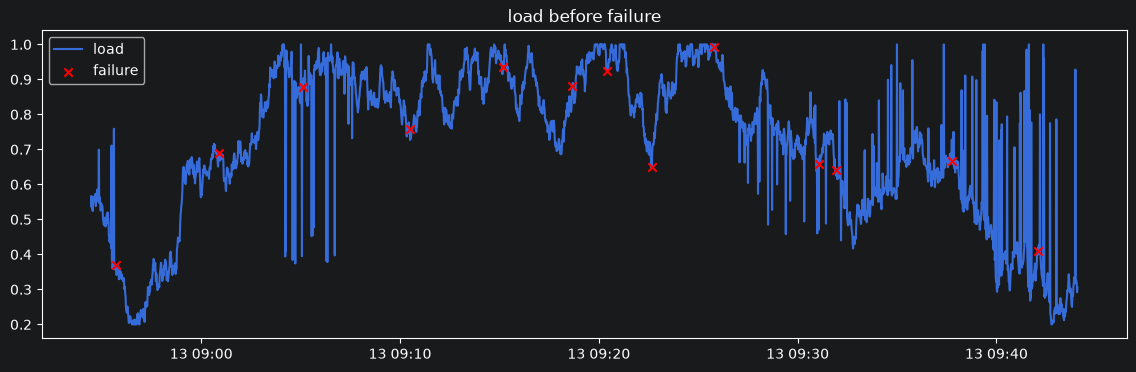

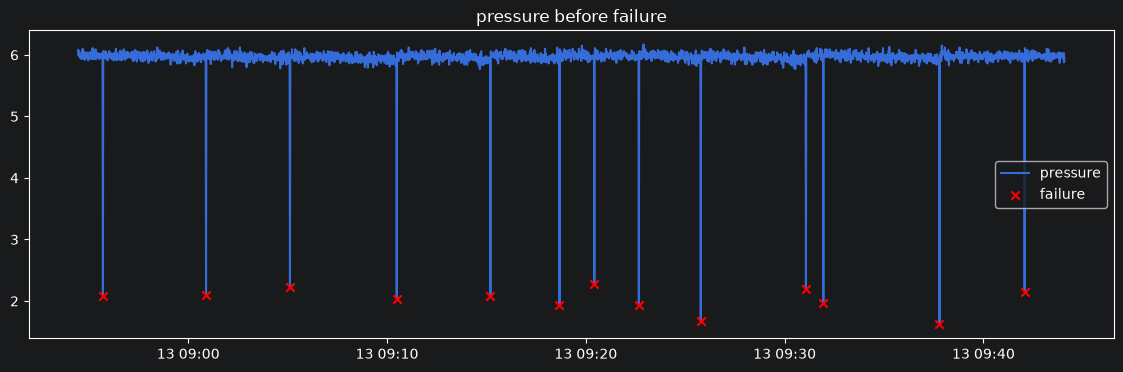

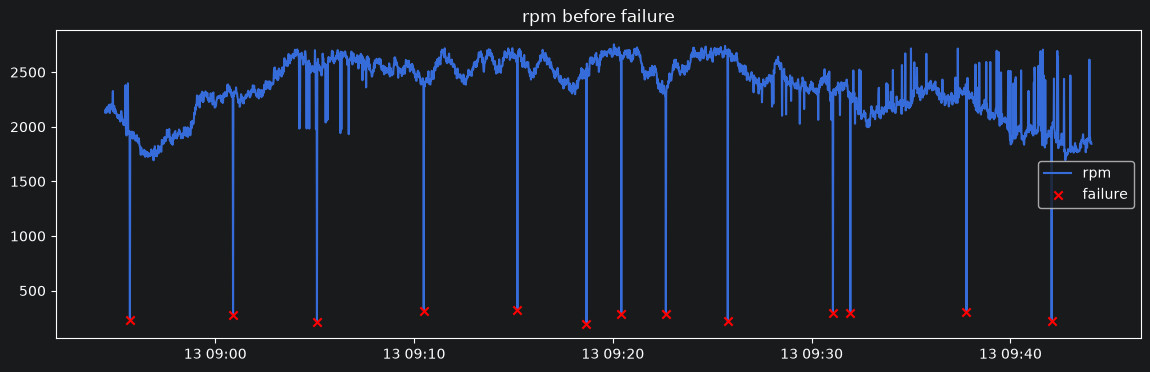

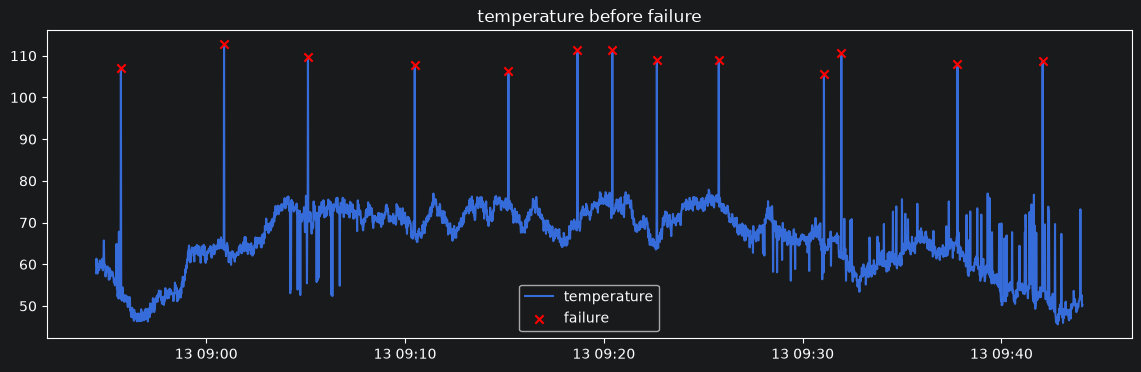

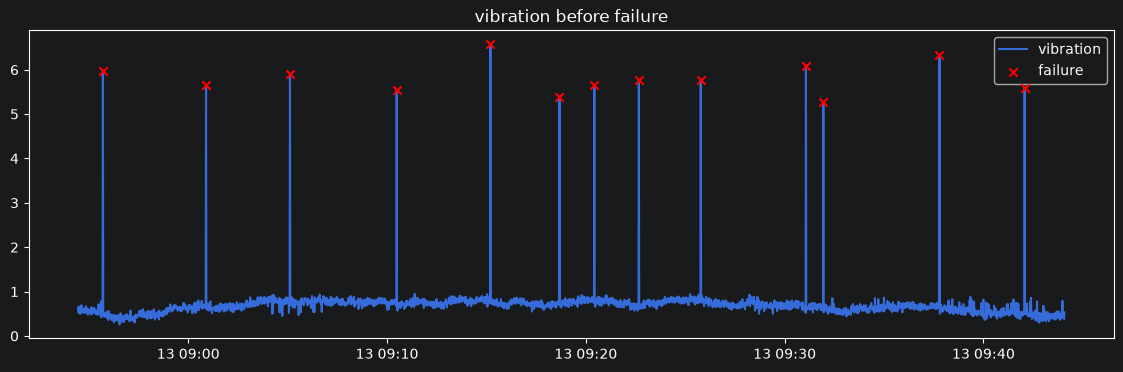

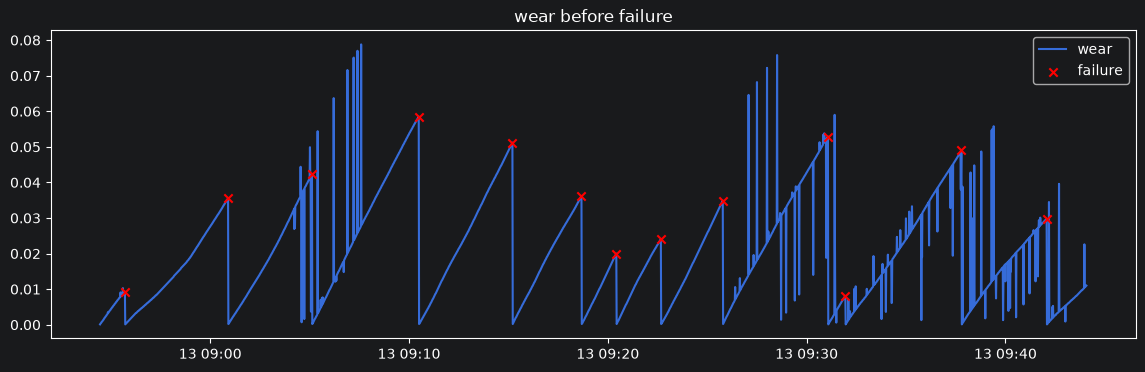

In [38]:
failure_points = subset[subset["failure"] == 1]

for feature in features:
    plt.figure(figsize=(14, 4))

    plt.plot(
        subset.index,
        subset[feature],
        label=feature,
        zorder=1
    )

    plt.scatter(
        failure_points.index,
        failure_points[feature],
        marker='x',
        label='failure',
        color='red',
        zorder=10
    )

    plt.title(f"{feature} before failure")
    plt.legend()
    plt.show()